In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
import warnings
import itertools

warnings.filterwarnings('ignore')

ticker = 'V'
data = yf.download(ticker, period='2mo', interval='1h')
df = data[['Close']].dropna()
print(f'Объем выборки: {len(df)} строк.')

[*********************100%***********************]  1 of 1 completed

Объем выборки: 294 строк.


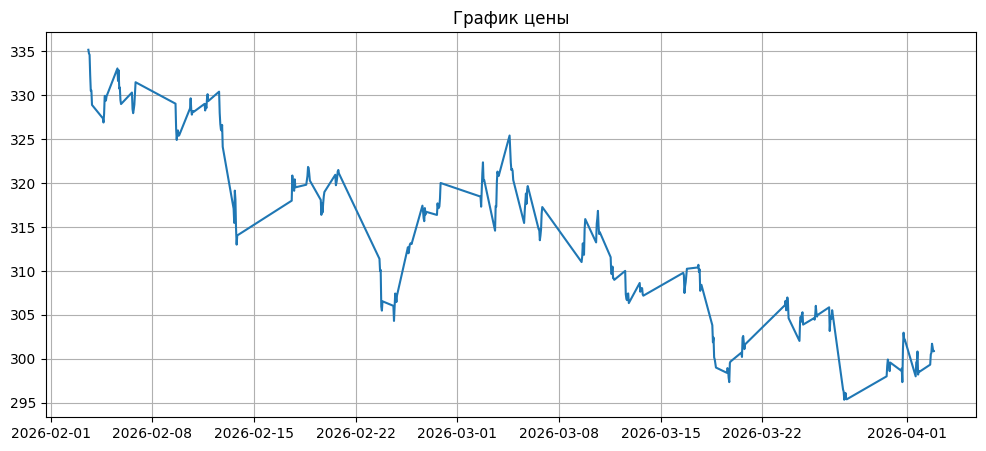

In [2]:
#2. График временного ряда
plt.figure(figsize=(12, 5))
plt.plot(df['Close'])
plt.title(f'График цены')
plt.grid(True)
plt.show()

In [3]:
#3. Проверка на стационарность
result = adfuller(df['Close'])
print(f'ADF: {result[0]:.4f}, p-value: {result[1]:.4f}')
if result[1] > 0.05:
    print('Ряд не стационарен')
else:
    print('Ряд стационарен')

ADF: -1.6671, p-value: 0.4481
Ряд не стационарен


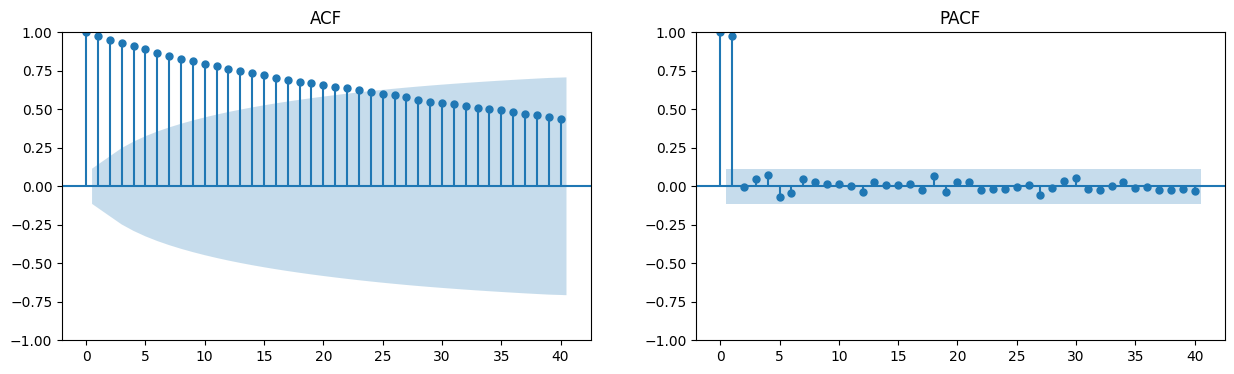

In [4]:
#4. Графики АКФ и ЧАКФ
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(df['Close'], lags=40, ax=axes[0])
plot_pacf(df['Close'], lags=40, ax=axes[1])
axes[0].set_title('ACF')
axes[1].set_title('PACF')
plt.show()

In [5]:
#5. Цикл перебора параметров p, d, q
train_size = int(len(df) * 0.8)
train, test = df['Close'][:train_size], df['Close'][train_size:]

p = q = range(0, 3)
d = range(0, 2)
pdq = list(itertools.product(p, d, q))

best_aic = float('inf')
best_order = None

start_time = time.time()
for param in pdq:
    try:
        model = ARIMA(train, order=param)
        res = model.fit()
        if res.aic < best_aic:
            best_aic = res.aic
            best_order = param
    except: continue
end_time = time.time()

print(f'Лучшая модель ARIMA {best_order} (AIC={best_aic:.2f})')

Лучшая модель ARIMA (2, 1, 2) (AIC=939.36)


In [6]:
# 6. Время расчетов
calc_time = end_time - start_time
print(f'Время выполнения цикла: {calc_time:.2f} сек')

Время выполнения цикла: 9.69 сек


In [7]:
# 7. MAPE
model_final = ARIMA(train, order=best_order)
results_final = model_final.fit()
forecast_test = results_final.forecast(steps=len(test))
mape = mean_absolute_percentage_error(test, forecast_test)
print(f'MAPE на тестовой выборке: {mape:.4%}')

MAPE на тестовой выборке: 1.5639%


In [8]:
# 8. Прогноз
forecast_10 = results_final.get_forecast(steps=10).summary_frame()
display(forecast_10[['mean', 'mean_ci_lower', 'mean_ci_upper']])

V,mean,mean_ci_lower,mean_ci_upper
235,306.277685,302.824512,309.730858
236,306.130862,301.086571,311.175154
237,305.854336,299.768117,311.940555
238,306.049494,299.139381,312.959608
239,306.247324,298.481610,314.013038
240,306.028155,297.469919,314.586391
241,305.905485,296.716877,315.094092
242,306.128030,296.345242,315.910819
243,306.183556,295.767337,316.599776
244,305.973947,294.981059,316.966836


In [9]:
# 10. Определение лучшей модели
mape_cv = []
parts = np.array_split(df['Close'], 3)

for i, part in enumerate(parts):
    split_idx = int(len(part) * 0.8)
    cv_train = part.iloc[:split_idx]
    cv_test = part.iloc[split_idx:]

    try:
        cv_model = ARIMA(cv_train, order=best_order).fit()
        cv_forecast = cv_model.forecast(steps=len(cv_test))

        err = mean_absolute_percentage_error(cv_test, cv_forecast)
        mape_cv.append(err)
        print(f'  Часть {i+1}: MAPE = {err:.4%}')
    except Exception as e:
        print(f'  Часть {i+1}: Ошибка при расчете ({e})')

  Часть 1: MAPE = 1.4409%
  Часть 2: MAPE = 1.4177%
  Часть 3: MAPE = 0.6519%
